# Mount Google Drive for Dataset
The dataset used in this study consists of 418 images representing three posture classes: Slouch, Proper, and Leaning Back. The data is relatively balanced, with 140 slouch images, 135 proper posture images, and 143 leaning back images. To evaluate the model effectively, the dataset was divided into 335 training images and 83 validation images.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Libraries and set parameters


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/Blurred Posture Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Image Preprocessing and Data Augmentation
The training images are augmented through small rotations, shifts, zooming, brightness changes, and horizontal flipping to improve the model’s ability to generalize.

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

# Loading Training and Validation Data
This section loads the dataset from class-based folders. The dataset is split into 80% training data and 20% validation data. The training data is shuffled, while the validation data is not shuffled so evaluation metrics and predictions remain consistent.

In [4]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Classes:", train_data.class_indices)

Found 335 images belonging to 3 classes.
Found 83 images belonging to 3 classes.
Classes: {'Leaning_back': 0, 'Proper': 1, 'slouch': 2}


# Loading the Pretrained MobileNetV2 Model
This section uses MobileNetV2 as the base model for transfer learning. MobileNetV2 was pretrained on ImageNet, allowing it to extract useful image features without training from scratch. The top classification layer is removed because a new classifier will be added for the posture classes.

In [5]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Building the Posture Classification Model
This section adds custom classification layers on top of MobileNetV2. GlobalAveragePooling2D reduces the extracted features, Dense layers learn posture-specific patterns, Dropout helps reduce overfitting, and the final Softmax layer outputs probabilities for the three posture classes.

In [6]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(train_data.num_classes, activation="softmax")
])

# Compiling the Model
This section configures the training process. Adam is used as the optimizer, categorical cross-entropy is used as the loss function because the task is multi-class classification, and accuracy is used as the main evaluation metric.

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Setting Training Callbacks
This section defines callbacks to improve training. Early stopping stops training when validation loss stops improving, preventing overfitting. Model checkpoint saves the best-performing model during training.

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_posture_mobilenetv2_augmented.keras",
    monitor="val_loss",
    save_best_only=True
)

# Training the model
This section trains the posture classification model using the training dataset and validates it using the validation dataset. The model is trained for up to 50 epochs, but early stopping may stop training earlier if performance stops improving.

In [9]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)
# Save history for later plotting
import json
with open('training_history.json', 'w') as f:
    json.dump(history.history, f)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 208s 17s/step - accuracy: 0.4776 - loss: 1.1216 - val_accuracy: 0.5663 - val_loss: 0.8709
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.7910 - loss: 0.5548 - val_accuracy: 0.7108 - val_loss: 0.7209
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.9045 - loss: 0.3477 - val_accuracy: 0.7590 - val_loss: 0.6382
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.9403 - loss: 0.2158 - val_accuracy: 0.7831 - val_loss: 0.5954
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.9642 - loss: 0.1511 - val_accuracy: 0.7831 - val_loss: 0.5585
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.9881 - loss: 0.0961 - val_accuracy: 0.8072 - val_loss: 0.5186
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.9791 - loss: 0.0930 - val_accuracy: 0.8193 - val_loss: 0.4691
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.9881 - loss: 0.0749 - val_accuracy: 0.8072 - val_los

# Saving the model


In [12]:
model.save("final_posture_mobilenetv2_augmented.keras")

In [20]:
from google.colab import files
files.download("final_posture_mobilenetv2_augmented.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Loading and Evaluating the Best Model
This section loads the best saved model from training and evaluates it on the validation dataset. The final validation accuracy and validation loss are displayed to measure model performance.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final_posture_mobilenetv2_augmented.keras to final_posture_mobilenetv2_augmented.keras


In [13]:
import tensorflow as tf

model = tf.keras.models.load_model("final_posture_mobilenetv2_augmented.keras")

In [14]:
best_model = tf.keras.models.load_model("final_posture_mobilenetv2_augmented.keras")

loss, acc = best_model.evaluate(validation_data)

print("Final Validation Accuracy:", round(acc, 4))
print("Final Validation Loss:", round(loss, 4))

3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.8916 - loss: 0.3241
Final Validation Accuracy: 0.8916
Final Validation Loss: 0.3241


# Visualizing Training Performance
This section plots the training and validation accuracy, as well as the training and validation loss. These graphs help determine whether the model is learning properly or overfitting.

Loaded training history from training_history.json


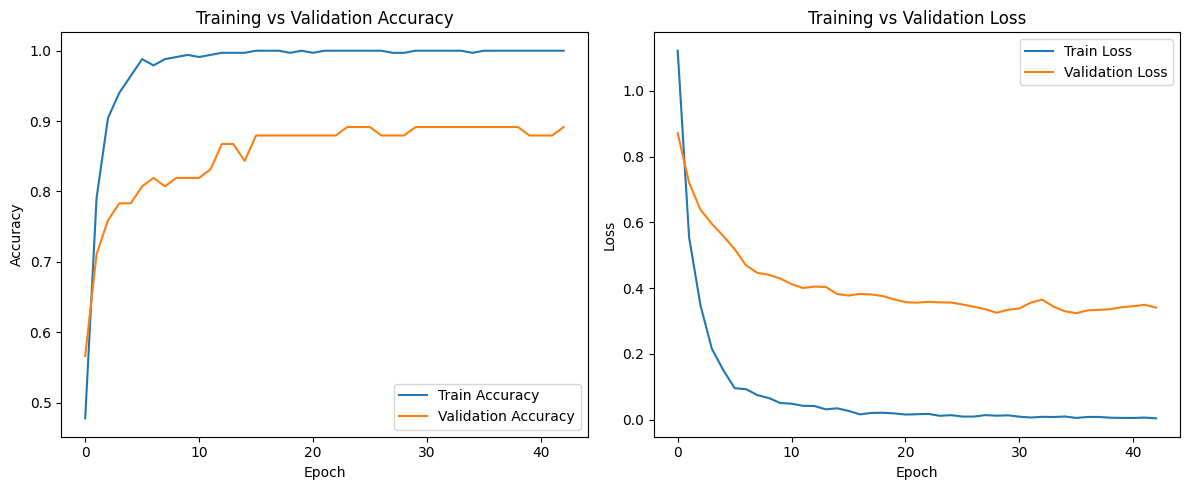

In [15]:
import json
import matplotlib.pyplot as plt

# Load history if not already defined (e.g., after kernel restart or loading a saved model)
try:
    with open('training_history.json', 'r') as f:
        loaded_history = json.load(f)
    # Create a simple object to mimic history.history
    history = type('obj', (object,), {'history' : loaded_history})()
    print("Loaded training history from training_history.json")
except FileNotFoundError:
    print("Training history file 'training_history.json' not found. Please ensure the model training cell has been run and saved the history.")
    history = None # Set history to None to prevent further errors

if history:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Skipping history plots as 'history' object is not available.")


# Confusion Matrix and Classification Report
This section evaluates the model more deeply by showing how many images were correctly and incorrectly classified per class. The classification report provides precision, recall, F1-score, and overall accuracy.

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(validation_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = validation_data.classes

print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes, target_names=validation_data.class_indices.keys()))


3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step
[[28  0  0]
 [ 0 27  0]
 [ 0  9 19]]
              precision    recall  f1-score   support

Leaning_back       1.00      1.00      1.00        28
      Proper       0.75      1.00      0.86        27
      slouch       1.00      0.68      0.81        28

    accuracy                           0.89        83
   macro avg       0.92      0.89      0.89        83
weighted avg       0.92      0.89      0.89        83



# Testing via upload

In [17]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model("final_posture_mobilenetv2_augmented.keras")

class_names = ["Leaning Back", "Proper", "Slouch"]  # make sure this matches your class_indices

In [18]:
from google.colab import files

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print("Prediction:", predicted_class)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("All probabilities:")

    for cls, prob in zip(class_names, prediction[0]):
        print(cls, ":", round(prob * 100, 2), "%")

uploaded = files.upload()

for filename in uploaded.keys():
    predict_image(filename)

# For anaconda env live webcam testing


In [21]:
model = tf.keras.models.load_model("final_posture_mobilenetv2_augmented.keras")
model.export("saved_model_posture")

Saved artifact at 'saved_model_posture'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140230729711696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729714768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729712656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729714384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729715344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729715728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729715920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729714960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729715536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140230729716496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402307297

In [22]:
import shutil
from google.colab import files

shutil.make_archive("saved_model_posture", "zip", "saved_model_posture")
files.download("saved_model_posture.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>